In [1]:
import json

# 打开文件并读取数据
with open('fine-tuned-models/nllb-200-distilled-600M/zh2ko_1025/trainer_state.json', 'r') as f:
    data = json.load(f)

data

{'best_metric': 0.01548257190734148,
 'best_model_checkpoint': 'autodl-tmp/nllb-200-distilled-600M/zh2ko/checkpoint-120000',
 'epoch': 1.935265373264309,
 'global_step': 120000,
 'is_hyper_param_search': False,
 'is_local_process_zero': True,
 'is_world_process_zero': True,
 'log_history': [{'epoch': 0.08,
   'learning_rate': 1.3425253991291728e-05,
   'loss': 4.1142,
   'step': 5000},
  {'epoch': 0.08,
   'eval_loss': 0.043007489293813705,
   'eval_runtime': 635.8387,
   'eval_samples_per_second': 24.38,
   'eval_steps_per_second': 24.38,
   'step': 5000},
  {'epoch': 0.16,
   'learning_rate': 2.6861258936730638e-05,
   'loss': 0.0385,
   'step': 10000},
  {'epoch': 0.16,
   'eval_loss': 0.02953464165329933,
   'eval_runtime': 634.7866,
   'eval_samples_per_second': 24.421,
   'eval_steps_per_second': 24.421,
   'step': 10000},
  {'epoch': 0.24,
   'learning_rate': 4.0299951620706336e-05,
   'loss': 0.0294,
   'step': 15000},
  {'epoch': 0.24,
   'eval_loss': 0.026134178042411804,
   

In [2]:
import pandas as pd

df = pd.DataFrame(data["log_history"])
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.08,0.000013,4.1142,5000,NaN,NaN,NaN,NaN
1,0.08,NaN,NaN,5000,0.043007,635.8387,24.380,24.380
2,0.16,0.000027,0.0385,10000,NaN,NaN,NaN,NaN
3,0.16,NaN,NaN,10000,0.029535,634.7866,24.421,24.421
4,0.24,0.000040,0.0294,15000,NaN,NaN,NaN,NaN
5,0.24,NaN,NaN,15000,0.026134,632.6084,24.505,24.505
6,0.32,0.000050,0.0276,20000,NaN,NaN,NaN,NaN
7,0.32,NaN,NaN,20000,0.024450,635.0019,24.413,24.413
8,0.40,0.000048,0.0249,25000,NaN,NaN,NaN,NaN
9,0.40,NaN,NaN,25000,0.022784,640.0380,24.220,24.220


In [3]:
df.set_index('epoch', inplace=True)
df = df.groupby(level=0).first()
df.reset_index(inplace=True)
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.08,0.000013,4.1142,5000,0.043007,635.8387,24.380,24.380
1,0.16,0.000027,0.0385,10000,0.029535,634.7866,24.421,24.421
2,0.24,0.000040,0.0294,15000,0.026134,632.6084,24.505,24.505
3,0.32,0.000050,0.0276,20000,0.024450,635.0019,24.413,24.413
4,0.40,0.000048,0.0249,25000,0.022784,640.0380,24.220,24.220
5,0.48,0.000047,0.0246,30000,0.021401,628.2138,24.676,24.676
6,0.56,0.000045,0.0230,35000,0.020779,633.6276,24.465,24.465
7,0.65,0.000044,0.0210,40000,0.019837,625.5517,24.781,24.781
8,0.73,0.000042,0.0212,45000,0.019429,627.2775,24.713,24.713
9,0.81,0.000041,0.0204,50000,0.018771,632.7390,24.500,24.500


In [4]:
df = df.iloc[1:]
df

,epoch,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
1,0.16,0.000027,0.0385,10000,0.029535,634.7866,24.421,24.421
2,0.24,0.000040,0.0294,15000,0.026134,632.6084,24.505,24.505
3,0.32,0.000050,0.0276,20000,0.024450,635.0019,24.413,24.413
4,0.40,0.000048,0.0249,25000,0.022784,640.0380,24.220,24.220
5,0.48,0.000047,0.0246,30000,0.021401,628.2138,24.676,24.676
6,0.56,0.000045,0.0230,35000,0.020779,633.6276,24.465,24.465
7,0.65,0.000044,0.0210,40000,0.019837,625.5517,24.781,24.781
8,0.73,0.000042,0.0212,45000,0.019429,627.2775,24.713,24.713
9,0.81,0.000041,0.0204,50000,0.018771,632.7390,24.500,24.500
10,0.89,0.000039,0.0203,55000,0.018321,638.0340,24.297,24.297


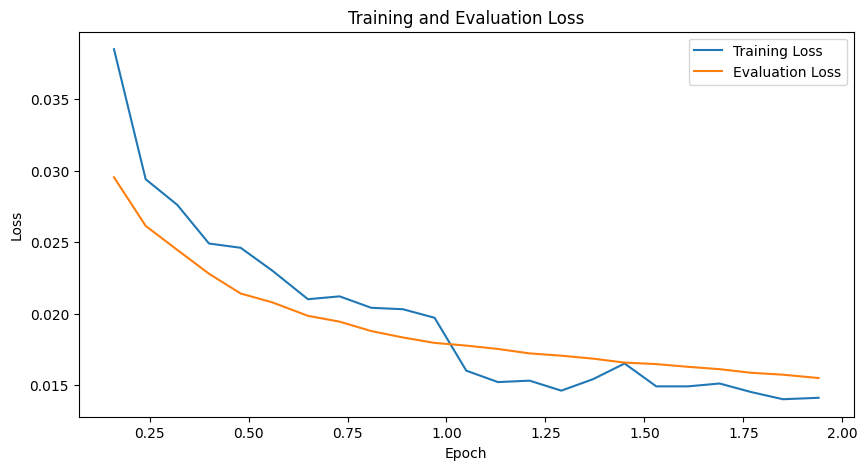

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['loss'], label='Training Loss')
plt.plot(df['epoch'], df['eval_loss'], label='Evaluation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.show()